In [1]:
import pandas as pd

# Load both files
df_non_expiry = pd.read_csv("Data/20260204_option_minute_prices_non_expiry.csv")
df_expiry     = pd.read_csv("Data/20260205_option_minute_prices_expiry.csv")

# Parse time properly
for df in [df_non_expiry, df_expiry]:
    df['date'] = pd.to_datetime(df['date'], format='%Y%m%d')
    df['minute_end'] = df['minute_end'].astype(str).str.zfill(6)

print("Non-expiry shape:", df_non_expiry.shape)
print("Expiry shape:", df_expiry.shape)
print(df_non_expiry.head())

Non-expiry shape: (8625, 4)
Expiry shape: (8625, 4)
        date minute_end             symbol  last_trade_price
0 2026-02-04     091600      NIFTY26FEBFUT         2575220.0
1 2026-02-04     091600  NIFTY2621025550CE           26215.0
2 2026-02-04     091600  NIFTY2621025600CE           23205.0
3 2026-02-04     091600  NIFTY2621025650CE           20300.0
4 2026-02-04     091600  NIFTY2621025700CE           17675.0


In [2]:
# February 5 - Expiry day data
df_feb05 = df_expiry.copy()

print(f"Successfully loaded expiry day data")
print(f"Shape: {df_feb05.shape}")

display(df_feb05.head())

Successfully loaded expiry day data
Shape: (8625, 4)


,date,minute_end,symbol,last_trade_price
0,2026-02-05,091600,NIFTY26FEBFUT,2578540.0
1,2026-02-05,091600,NIFTY2621025600CE,23115.0
2,2026-02-05,091600,NIFTY2621025650CE,19995.0
3,2026-02-05,091600,NIFTY2621025700CE,17140.0
4,2026-02-05,091600,NIFTY2621025750CE,14535.0


### Step 1: Filter Data and Extract Futures Price
First, we'll filter the DataFrame for options data at 11:00:00 (which corresponds to `minute_end = 110000`). We'll also extract the future price and parse the option symbols to get the strike prices and whether they are Call (CE) or Put (PE) options.

In [3]:
import numpy as np
import pandas as pd
import os

os.chdir(r"C:\Users\COMPUTER WORLD IT\OneDrive\Desktop\Delta Hedging & Adversarial Stock Path Generation Simulator")

# Load expiry day data
df_feb05 = pd.read_csv("Data/20260205_option_minute_prices_expiry.csv")

# Fix data types
df_feb05['minute_end'] = df_feb05['minute_end'].astype(str).str.zfill(6)
df_feb05['date'] = pd.to_datetime(df_feb05['date'].astype(str), format='%Y%m%d')

# Filter for 11 AM — use STRING '110000' not integer
filtered_df = df_feb05[df_feb05['minute_end'] == '110000'].copy()
print(f"Rows at 11 AM: {len(filtered_df)}")

# Extract Future Price
futures_row = filtered_df[filtered_df['symbol'].str.contains('FUT')]
if not futures_row.empty:
    S = futures_row['last_trade_price'].iloc[0]
    print(f"Future Price (S) at 11 AM: ₹{S/100:.2f}")
else:
    S = None
    print("Future price not found!")

# Filter out futures — keep only options
options_df = filtered_df[~filtered_df['symbol'].str.contains('FUT')].copy()
print(f"Options rows: {len(options_df)}")

# Fixed parse_symbol function
def parse_symbol(symbol):
    try:
        if 'CE' in symbol:
            option_type = 'call'
            strike_part = symbol.split('CE')[0]
            digits_only = ''.join(filter(str.isdigit, strike_part))
            if len(digits_only) >= 5:
                return float(digits_only[-5:]), option_type
        elif 'PE' in symbol:
            option_type = 'put'
            strike_part = symbol.split('PE')[0]
            digits_only = ''.join(filter(str.isdigit, strike_part))
            if len(digits_only) >= 5:
                return float(digits_only[-5:]), option_type
        return None, None
    except:
        return None, None

# Apply parser safely
parsed = options_df['symbol'].apply(parse_symbol)
options_df['strike']      = parsed.apply(lambda x: x[0])
options_df['option_type'] = parsed.apply(lambda x: x[1])

# Drop unparseable rows
options_df.dropna(subset=['strike', 'option_type'], inplace=True)
print(f"Options after parsing: {len(options_df)}")

# Fix strike price (paise to rupees)
options_df['strike'] = options_df['strike'] * 100.0

# Build datetime
options_df['observation_datetime'] = pd.to_datetime(
    df_feb05['date'].astype(str).str[:10].iloc[0] + ' ' + '11:00:00'
)

# Time to expiry
expiration_date = pd.to_datetime('2026-02-05 15:30:00')
options_df['T'] = (
    expiration_date - options_df['observation_datetime']
).dt.total_seconds() / (365.25 * 24 * 3600)

# Risk free rate
r = 0.05

print(f"\nS = {S}")
print(f"T = {options_df['T'].iloc[0]:.6f} years")
print(f"\nSample options:")
display(options_df[['symbol','strike','option_type','last_trade_price','T']].head())

# Convert ALL prices from paise to rupees
S_rupees = S / 100
options_df['strike_rs']          = options_df['strike'] / 100
options_df['last_trade_price_rs'] = options_df['last_trade_price'] / 100

print(f"\nS in rupees: ₹{S_rupees:.2f}")
print(f"Sample strikes in rupees:")
print(options_df['strike_rs'].head())
print(f"Sample option prices in rupees:")
print(options_df['last_trade_price_rs'].head())

Rows at 11 AM: 23
Future Price (S) at 11 AM: ₹25715.10
Options rows: 22
Options after parsing: 22

S = 2571510.0
T = 0.000513 years

Sample options:


,symbol,strike,option_type,last_trade_price,T
2393,NIFTY2621025600CE,2560000.0,call,16790.0,0.000513
2394,NIFTY2621025650CE,2565000.0,call,14115.0,0.000513
2395,NIFTY2621025700CE,2570000.0,call,11770.0,0.000513
2396,NIFTY2621025750CE,2575000.0,call,9725.0,0.000513
2397,NIFTY2621025800CE,2580000.0,call,7990.0,0.000513



S in rupees: ₹25715.10
Sample strikes in rupees:
2393    25600.0
2394    25650.0
2395    25700.0
2396    25750.0
2397    25800.0
Name: strike_rs, dtype: float64
Sample option prices in rupees:
2393    167.90
2394    141.15
2395    117.70
2396     97.25
2397     79.90
Name: last_trade_price_rs, dtype: float64


### Step 2: Define Black-Scholes Model and Greeks Calculation

Next, we'll implement the Black-Scholes formula to calculate option prices and the associated Greeks (Delta, Gamma, Theta). We'll use `scipy.stats.norm` for the cumulative distribution function (CDF).

In [4]:
from scipy.stats import norm

def black_scholes(S, K, T, r, sigma, option_type):
    if T <= 0: # Handle zero or negative time to expiration
        if option_type == 'call':
            return max(0, S - K), 0, 0, 0
        else:
            return max(0, K - S), 0, 0, 0

    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option_type == 'call':
        price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
        delta = norm.cdf(d1)
        gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
        theta = -(S * norm.pdf(d1) * sigma) / (2 * np.sqrt(T)) - r * K * np.exp(-r * T) * norm.cdf(d2)
    elif option_type == 'put':
        price = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
        delta = norm.cdf(d1) - 1
        gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
        theta = -(S * norm.pdf(d1) * sigma) / (2 * np.sqrt(T)) + r * K * np.exp(-r * T) * norm.cdf(-d2)
    else:
        raise ValueError("option_type must be 'call' or 'put'")

    return price, delta, gamma, theta

print("Black-Scholes function defined.")

Black-Scholes function defined.


### Step 3: Define Implied Volatility (IV) Solver

Calculating Implied Volatility (IV) involves finding the volatility that, when plugged into the Black-Scholes formula, yields the observed market price of the option. This requires an iterative method, as there's no direct algebraic solution. We'll use a simple bisection method for this.

In [5]:
def implied_volatility(market_price, S, K, T, r, option_type, 
                       tol=0.0001, max_iter=500, verbose=False):
    """
    Calculate Implied Volatility using Bisection Method.
    
    Parameters:
        market_price : observed option price from NSE
        S            : current futures price (NIFTY)
        K            : strike price
        T            : time to expiry in years
        r            : risk-free rate (0.05)
        option_type  : 'call' or 'put'
        tol          : tolerance for convergence (default 0.0001)
        max_iter     : maximum iterations (default 500)
        verbose      : print debug info (default False)
    
    Returns:
        mid_vol : implied volatility (sigma)
    """
    
    # Step 1 — Handle expired options
    if T <= 0:
        return 0.0
    
    # Step 2 — Check if price is valid
    if market_price <= 0:
        return np.nan
    
    # Step 3 — Set initial bounds for bisection
    low_vol  = 0.001   # 0.1% volatility — absolute minimum
    high_vol = 5.000   # 500% volatility — absolute maximum
    mid_vol  = (low_vol + high_vol) / 2
    
    # Step 4 — Check if solution exists within bounds
    price_low,  _, _, _ = black_scholes(S, K, T, r, low_vol,  option_type)
    price_high, _, _, _ = black_scholes(S, K, T, r, high_vol, option_type)
    
    if market_price < price_low:
        if verbose:
            print(f"Market price {market_price} below minimum BS price {price_low:.4f}")
        return np.nan
    
    if market_price > price_high:
        if verbose:
            print(f"Market price {market_price} above maximum BS price {price_high:.4f}")
        return np.nan
    
    # Step 5 — Bisection loop
    for i in range(max_iter):
        mid_vol = (low_vol + high_vol) / 2
        
        # Calculate BS price at midpoint volatility
        price_mid, _, _, _ = black_scholes(S, K, T, r, mid_vol, option_type)
        
        # Calculate difference between BS price and market price
        diff = price_mid - market_price
        
        if verbose and i % 50 == 0:
            print(f"Iter {i}: low={low_vol:.4f}, mid={mid_vol:.4f}, "
                  f"high={high_vol:.4f}, diff={diff:.4f}")
        
        # Check convergence
        if abs(diff) < tol:
            if verbose:
                print(f"Converged at iter {i}, IV = {mid_vol:.4f}")
            return mid_vol
        
        # Narrow the bounds
        if diff > 0:
            high_vol = mid_vol  # BS price too high → reduce volatility
        else:
            low_vol = mid_vol   # BS price too low  → increase volatility
    
    # Return best guess if max iterations reached
    return mid_vol

print("Implied Volatility (Bisection) function defined.")

Implied Volatility (Bisection) function defined.


### Step 4: Calculate Implied Volatility for all options

Now, we'll apply the `implied_volatility` function to each option in our filtered DataFrame. We'll add a new column for the calculated IV. We will handle cases where the future price `S` might not be available or where IV calculation fails.

In [6]:
if S is not None:
    options_df['implied_volatility'] = options_df.apply(
        lambda row: implied_volatility(
            row['last_trade_price_rs'],  # market price in rupees
            S_rupees,                    # futures price in rupees
            row['strike_rs'],            # strike in rupees
            row['T'],
            r,
            row['option_type'],
            verbose=False                # turn off verbose to reduce output
        ) if row['T'] > 0 else 0, axis=1
    )
else:
    options_df['implied_volatility'] = np.nan
    print("Cannot calculate IV — S not available")

print(f"\nIV Calculation complete!")
display(options_df[['symbol','strike_rs','option_type',
                     'last_trade_price_rs','implied_volatility']].head(10))


IV Calculation complete!


,symbol,strike_rs,option_type,last_trade_price_rs,implied_volatility
2393,NIFTY2621025600CE,25600.0,call,167.90,0.429009
2394,NIFTY2621025650CE,25650.0,call,141.15,0.452364
2395,NIFTY2621025700CE,25700.0,call,117.70,0.471846
2396,NIFTY2621025750CE,25750.0,call,97.25,0.488194
2397,NIFTY2621025800CE,25800.0,call,79.90,0.503553
2398,NIFTY2621025850CE,25850.0,call,64.90,0.516178
2399,NIFTY2621025900CE,25900.0,call,52.75,0.530051
2400,NIFTY2621025950CE,25950.0,call,42.60,0.542846
2401,NIFTY2621026000CE,26000.0,call,34.95,0.559509
2402,NIFTY2621026050CE,26050.0,call,27.95,0.570695


### Plot: Implied Volatility

Let's visualize the calculated Implied Volatility against the strike price. This plot often reveals the 'volatility smile' or 'volatility skew,' indicating how market participants perceive future volatility across different strike prices.

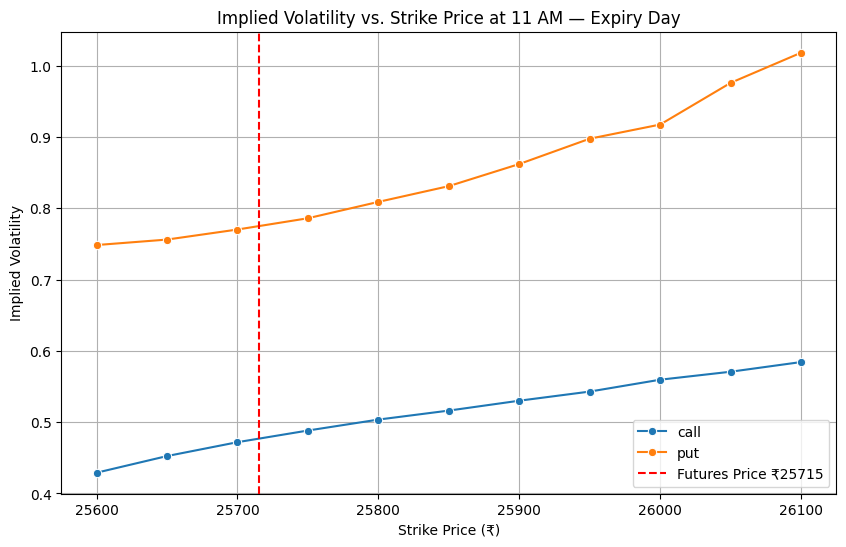

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.lineplot(data=options_df, x='strike_rs', y='implied_volatility', 
             hue='option_type', marker='o')
plt.title('Implied Volatility vs. Strike Price at 11 AM — Expiry Day')
plt.xlabel('Strike Price (₹)')
plt.ylabel('Implied Volatility')
plt.axvline(x=S_rupees, color='red', linestyle='--', label=f'Futures Price ₹{S_rupees:.0f}')
plt.legend()
plt.grid(True)
plt.show()

### Step 5: Calculate Greeks for all options using Implied Volatility

With the implied volatility calculated, we can now use it in the Black-Scholes model to derive the Delta, Gamma, and Theta for each option.

In [8]:
if S is not None:
    options_df[['bs_price', 'delta', 'gamma', 'theta']] = options_df.apply(
        lambda row:
            pd.Series(black_scholes(
                S_rupees,           # ← rupees not paise
                row['strike_rs'],   # ← rupees not paise
                row['T'],
                r,
                row['implied_volatility'],
                row['option_type']
            ))
        if row['T'] > 0 and not pd.isna(row['implied_volatility'])
        else pd.Series([np.nan, np.nan, np.nan, np.nan]), axis=1
    )
else:
    options_df[['bs_price', 'delta', 'gamma', 'theta']] = np.nan
    print("Cannot calculate Greeks — S not available.")

print("Greeks calculated!")
display(options_df[['symbol','strike_rs','option_type',
                     'last_trade_price_rs','implied_volatility',
                     'delta','gamma','theta']].head(10))

Greeks calculated!


,symbol,strike_rs,option_type,last_trade_price_rs,implied_volatility,delta,gamma,theta
2393,NIFTY2621025600CE,25600.0,call,167.90,0.429009,0.680472,0.001430,-87875.022860
2394,NIFTY2621025650CE,25650.0,call,141.15,0.452364,0.600617,0.001465,-99902.536916
2395,NIFTY2621025700CE,25700.0,call,117.70,0.471846,0.524993,0.001448,-107281.935470
2396,NIFTY2621025750CE,25750.0,call,97.25,0.488194,0.454316,0.001393,-110377.550044
2397,NIFTY2621025800CE,25800.0,call,79.90,0.503553,0.389375,0.001307,-110085.946530
2398,NIFTY2621025850CE,25850.0,call,64.90,0.516178,0.330206,0.001204,-106529.246862
2399,NIFTY2621025900CE,25900.0,call,52.75,0.530051,0.278119,0.001086,-101278.206574
2400,NIFTY2621025950CE,25950.0,call,42.60,0.542846,0.232362,0.000966,-94372.010507
2401,NIFTY2621026000CE,26000.0,call,34.95,0.559509,0.194677,0.000845,-87701.031421
2402,NIFTY2621026050CE,26050.0,call,27.95,0.570695,0.160537,0.000733,-79176.633911


### Step 6: Plot Delta

Let's visualize how Delta varies with the strike price for both Call and Put options. Delta measures the sensitivity of the option price to changes in the underlying asset's price.

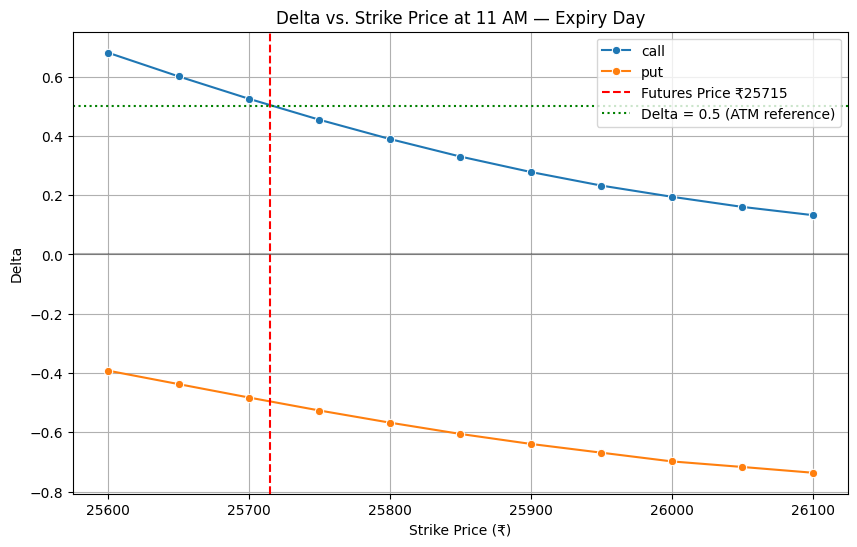

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.lineplot(data=options_df, x='strike_rs', y='delta', 
             hue='option_type', marker='o')

plt.title('Delta vs. Strike Price at 11 AM — Expiry Day')
plt.xlabel('Strike Price (₹)')
plt.ylabel('Delta')
plt.axvline(x=S_rupees, color='red', linestyle='--', 
            label=f'Futures Price ₹{S_rupees:.0f}')
plt.axhline(y=0.5, color='green', linestyle=':', 
            label='Delta = 0.5 (ATM reference)')
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
plt.legend()
plt.grid(True)
plt.show()


Step 7: Plot Gamma
Now, we'll plot Gamma against the strike price. Gamma measures the rate of change of Delta with respect to changes in the underlying asset's price, indicating how sensitive Delta is.

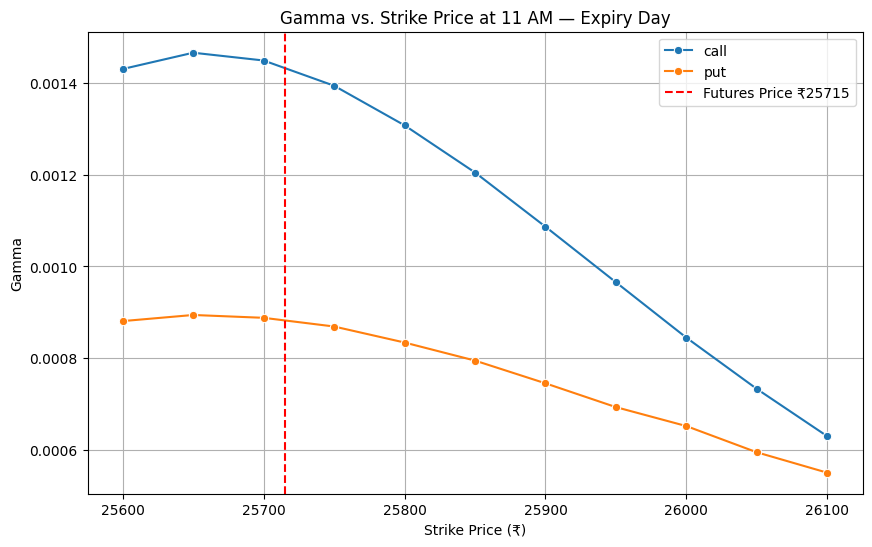

In [10]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=options_df, x='strike_rs', y='gamma',
             hue='option_type', marker='o')

plt.title('Gamma vs. Strike Price at 11 AM — Expiry Day')
plt.xlabel('Strike Price (₹)')
plt.ylabel('Gamma')
plt.axvline(x=S_rupees, color='red', linestyle='--',
            label=f'Futures Price ₹{S_rupees:.0f}')
plt.legend()
plt.grid(True)
plt.show()

### Step 8: Plot Theta

Next, we'll visualize Theta against the strike price. Theta, also known as 'time decay,' measures the rate at which an option's price erodes as time passes, all else being equal.

Most negative daily Theta:
  call: ₹-302.40 per day
  put: ₹-514.82 per day


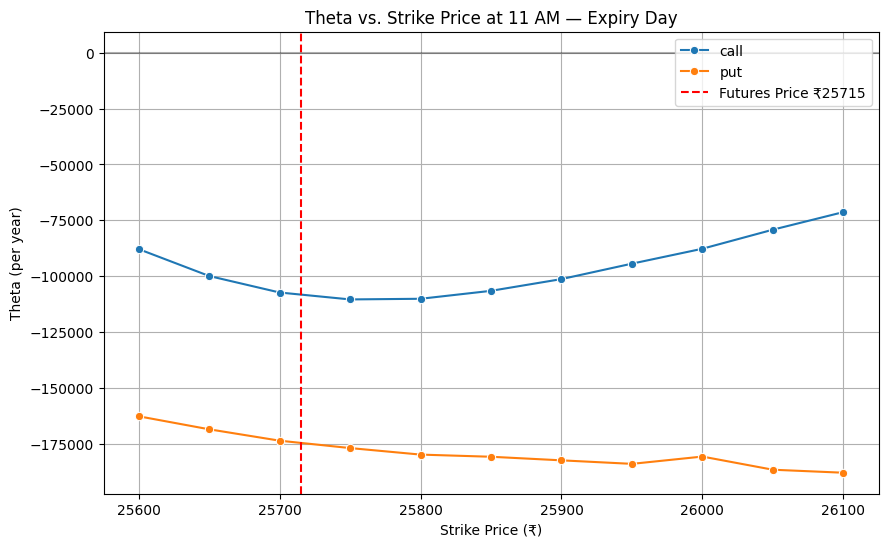

In [11]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=options_df, x='strike_rs', y='theta',
             hue='option_type', marker='o')

plt.title('Theta vs. Strike Price at 11 AM — Expiry Day')
plt.xlabel('Strike Price (₹)')
plt.ylabel('Theta (per year)')
plt.axvline(x=S_rupees, color='red', linestyle='--',
            label=f'Futures Price ₹{S_rupees:.0f}')
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)

# Add daily theta as secondary info
daily_theta = options_df.groupby('option_type')['theta'].min() / 365
print("Most negative daily Theta:")
for opt, val in daily_theta.items():
    print(f"  {opt}: ₹{val:.2f} per day")

plt.legend()
plt.grid(True)
plt.show()

Futures rows : 375
Option rows  : 375
Merged rows  : 375
Time range   : 2026-02-05 09:16:00 → 2026-02-05 15:30:00

Starting Delta Hedging Simulation...
Target: NIFTY2621025700CE | Strike: ₹25700.0 | Type: call

DELTA HEDGING RESULTS
Final NIFTY Price (S_T)        : ₹25720.00
Strike Price (K)               : ₹25700.00
Option Payoff at Expiry (-Z_T) : ₹-20.00
Cumulative Trading P&L         : ₹-48.76
Total P&L (PL_T)               : ₹-68.76


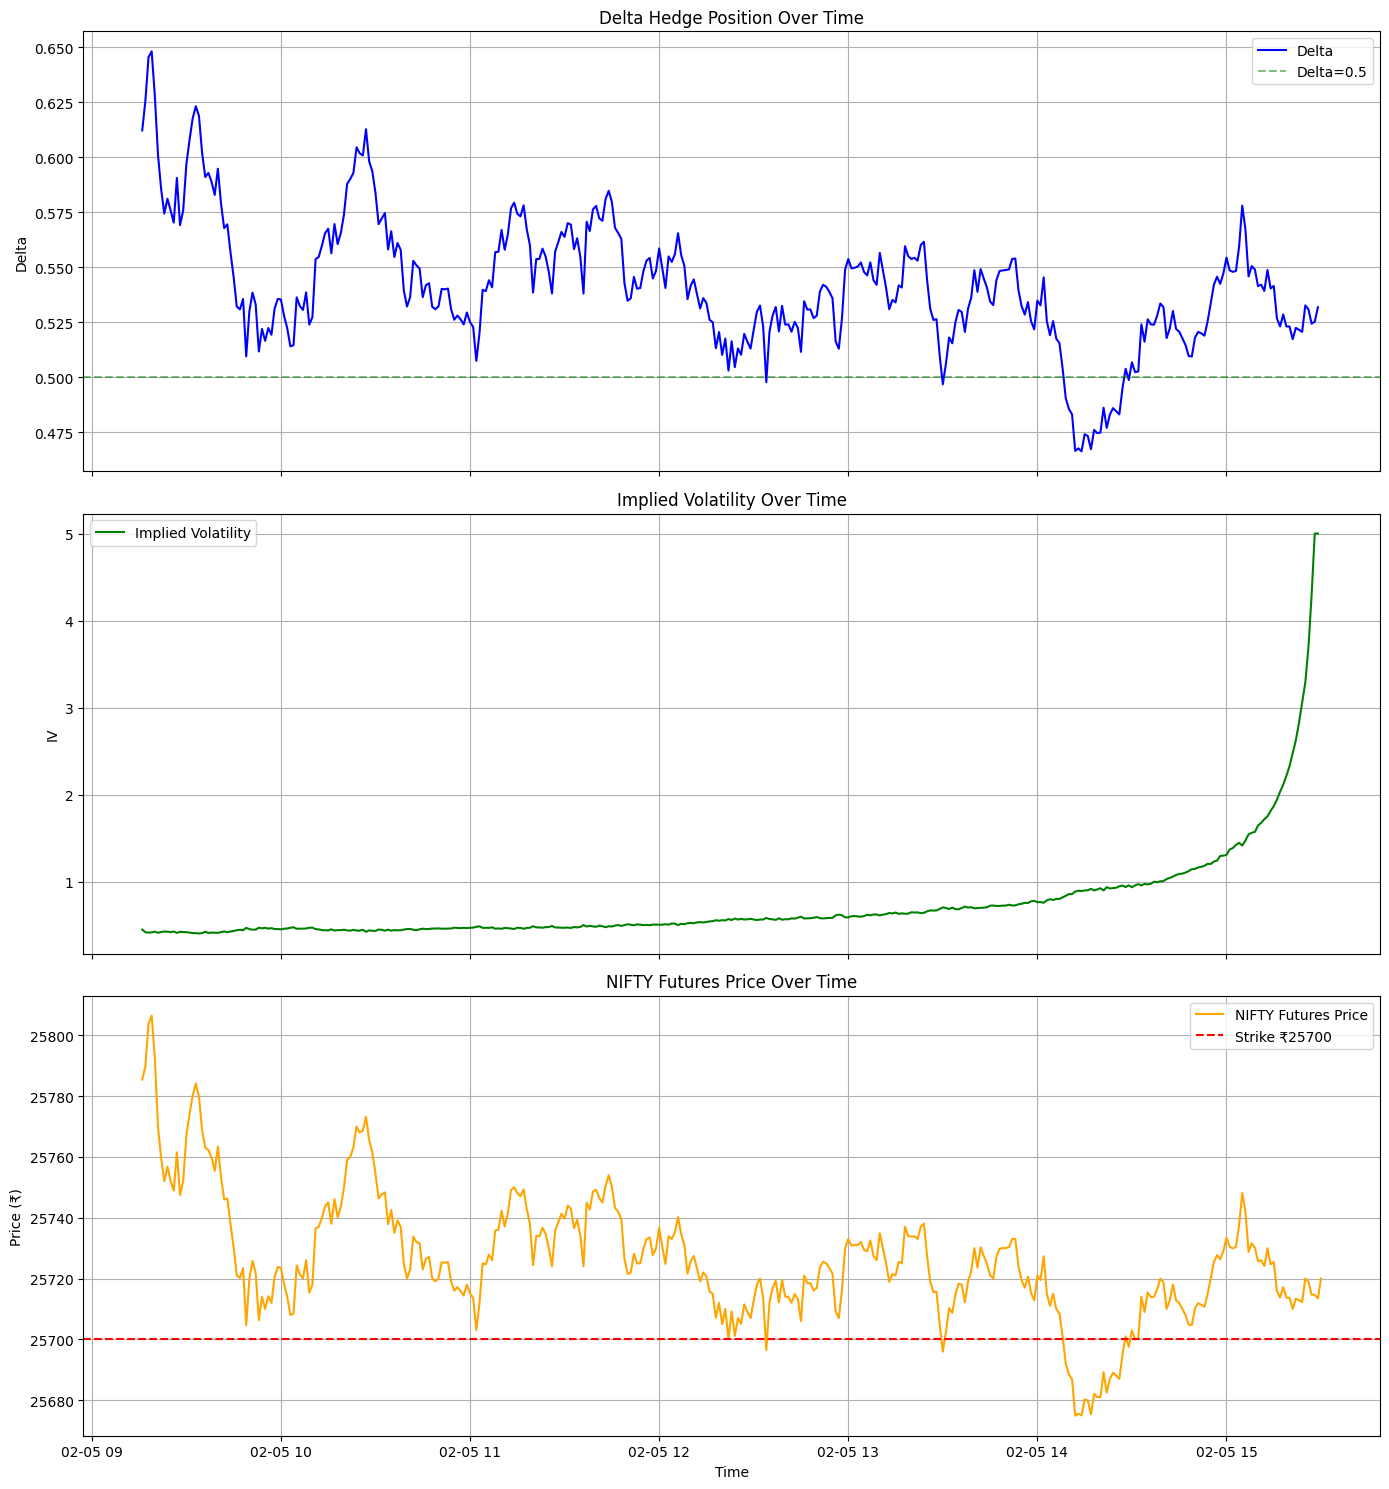

In [12]:
import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt
import seaborn as sns

# --- Black-Scholes function ---
def black_scholes(S, K, T, r, sigma, option_type):
    if T <= 0:
        if option_type == 'call':
            delta = 1.0 if S > K else 0.0
            return max(0, S - K), delta, 0, 0
        else:
            delta = -1.0 if S < K else 0.0
            return max(0, K - S), delta, 0, 0

    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option_type == 'call':
        price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
        delta = norm.cdf(d1)
        gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
        theta = -(S * norm.pdf(d1) * sigma) / (2 * np.sqrt(T)) - r * K * np.exp(-r * T) * norm.cdf(d2)
    elif option_type == 'put':
        price = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
        delta = norm.cdf(d1) - 1
        gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
        theta = -(S * norm.pdf(d1) * sigma) / (2 * np.sqrt(T)) + r * K * np.exp(-r * T) * norm.cdf(-d2)
    else:
        raise ValueError("option_type must be 'call' or 'put'")

    return price, delta, gamma, theta


# --- Implied Volatility solver ---
def implied_volatility(observed_price, S, K, T, r, option_type, tol=1e-5, max_iter=100):
    if T <= 0:
        return 0
    low_vol  = 0.001
    high_vol = 5.0

    for i in range(max_iter):
        mid_vol = (low_vol + high_vol) / 2
        if mid_vol < 1e-6:
            mid_vol = 1e-6

        bs_price, _, _, _ = black_scholes(S, K, T, r, mid_vol, option_type)

        if abs(bs_price - observed_price) < tol:
            return mid_vol
        if bs_price < observed_price:
            low_vol = mid_vol
        else:
            high_vol = mid_vol
        if (high_vol - low_vol) < tol:
            return mid_vol

    return mid_vol


# ─────────────────────────────────────────────
# TARGET OPTION — ATM Call ₹25700
# ─────────────────────────────────────────────
target_strike_paise  = 2570000.0
target_strike_rs     = target_strike_paise / 100   # ₹25700
target_option_type   = 'call'
target_symbol        = 'NIFTY2621025700CE'
r                    = 0.05

# ─────────────────────────────────────────────
# PREPARE MINUTE-BY-MINUTE DATA
# ─────────────────────────────────────────────
df_iv_hedge = df_feb05.copy()

# Fix minute_end to string
df_iv_hedge['minute_end'] = df_iv_hedge['minute_end'].astype(str).str.zfill(6)

# Build datetime column
df_iv_hedge['observation_datetime'] = pd.to_datetime(
    df_iv_hedge['date'].astype(str).str[:10] + ' ' +
    df_iv_hedge['minute_end'].str[:2] + ':' +
    df_iv_hedge['minute_end'].str[2:4] + ':' +
    df_iv_hedge['minute_end'].str[4:6]
)

expiration_date = pd.to_datetime('2026-02-05 15:30:00')

# Split into futures and target option
future_prices_df = df_iv_hedge[df_iv_hedge['symbol'].str.contains('FUT')].copy()
option_prices_df = df_iv_hedge[df_iv_hedge['symbol'] == target_symbol].copy()

print(f"Futures rows : {len(future_prices_df)}")
print(f"Option rows  : {len(option_prices_df)}")

# Merge on datetime
time_series_merged = pd.merge(
    future_prices_df, option_prices_df,
    on='observation_datetime',
    suffixes=('_fut', '_opt')
)
time_series_merged = time_series_merged.sort_values(
    'observation_datetime').reset_index(drop=True)

# Time to expiry in years
time_series_merged['T'] = (
    expiration_date - time_series_merged['observation_datetime']
).dt.total_seconds() / (365.25 * 24 * 3600)

print(f"Merged rows  : {len(time_series_merged)}")
print(f"Time range   : {time_series_merged['observation_datetime'].min()} → "
      f"{time_series_merged['observation_datetime'].max()}")

# ─────────────────────────────────────────────
# DELTA HEDGING LOOP — MINUTE BY MINUTE
# ─────────────────────────────────────────────
cumulative_trading_pnl = 0.0
delta_history          = []
iv_history             = []
asset_price_history    = []
pnl_history            = []

print(f"\nStarting Delta Hedging Simulation...")
print(f"Target: {target_symbol} | Strike: ₹{target_strike_rs} | Type: {target_option_type}")

for i in range(len(time_series_merged) - 1):

    # Current minute prices — convert paise → rupees
    S_ti  = time_series_merged['last_trade_price_fut'].iloc[i] / 100
    P_ti  = time_series_merged['last_trade_price_opt'].iloc[i] / 100
    T_ti  = time_series_merged['T'].iloc[i]

    # Calculate live IV
    current_iv = implied_volatility(
        P_ti, S_ti, target_strike_rs, T_ti, r, target_option_type
    )

    # Fallback if IV fails
    if pd.isna(current_iv) or current_iv <= 0:
        current_iv = iv_history[-1] if iv_history else 0.6

    # Calculate Delta using live IV
    _, current_delta, _, _ = black_scholes(
        S_ti, target_strike_rs, T_ti, r, current_iv, target_option_type
    )

    # Next minute futures price
    S_next = time_series_merged['last_trade_price_fut'].iloc[i + 1] / 100

    # P&L this minute = Delta × price change
    pnl_this_minute = current_delta * (S_next - S_ti)
    cumulative_trading_pnl += pnl_this_minute

    # Store history
    delta_history.append(current_delta)
    iv_history.append(current_iv)
    asset_price_history.append(S_ti)
    pnl_history.append(cumulative_trading_pnl)

# ─────────────────────────────────────────────
# FINAL P&L AT EXPIRY
# ─────────────────────────────────────────────
S_T = time_series_merged['last_trade_price_fut'].iloc[-1] / 100
option_payoff = max(0, S_T - target_strike_rs)  # call payoff

PL_T = -option_payoff + cumulative_trading_pnl

print(f"\n{'='*50}")
print(f"DELTA HEDGING RESULTS")
print(f"{'='*50}")
print(f"Final NIFTY Price (S_T)        : ₹{S_T:.2f}")
print(f"Strike Price (K)               : ₹{target_strike_rs:.2f}")
print(f"Option Payoff at Expiry (-Z_T) : ₹{-option_payoff:.2f}")
print(f"Cumulative Trading P&L         : ₹{cumulative_trading_pnl:.2f}")
print(f"Total P&L (PL_T)               : ₹{PL_T:.2f}")
print(f"{'='*50}")

# ─────────────────────────────────────────────
# PLOTS
# ─────────────────────────────────────────────
timestamps = time_series_merged['observation_datetime'].iloc[:-1]

fig, axes = plt.subplots(3, 1, figsize=(14, 15), sharex=True)

# Plot 1 — Delta over time
axes[0].plot(timestamps, delta_history, color='blue', label='Delta')
axes[0].set_title('Delta Hedge Position Over Time')
axes[0].set_ylabel('Delta')
axes[0].axhline(y=0.5, color='green', linestyle='--', alpha=0.5, label='Delta=0.5')
axes[0].grid(True)
axes[0].legend()

# Plot 2 — IV over time
axes[1].plot(timestamps, iv_history, color='green', label='Implied Volatility')
axes[1].set_title('Implied Volatility Over Time')
axes[1].set_ylabel('IV')
axes[1].grid(True)
axes[1].legend()

# Plot 3 — Futures price over time
axes[2].plot(
    time_series_merged['observation_datetime'],
    time_series_merged['last_trade_price_fut'] / 100,
    color='orange', label='NIFTY Futures Price'
)
axes[2].axhline(y=target_strike_rs, color='red', linestyle='--',
                label=f'Strike ₹{target_strike_rs:.0f}')
axes[2].set_title('NIFTY Futures Price Over Time')
axes[2].set_xlabel('Time')
axes[2].set_ylabel('Price (₹)')
axes[2].grid(True)
axes[2].legend()

plt.tight_layout()
plt.show()

### Explanation of the Profit & Loss (PL) Equation for the Hedger

The Profit & Loss (PL) of the hedger (the option issuer) is formulated as follows:

**Equation (1): Total P&L**

`PL_T (Z, S, δ) := -Z(S) + (δ · S)_T - C_T(δ)`

Let's break down each component:

*   `PL_T`: This represents the total Profit & Loss at time `T` (expiry) for the hedger. A positive `PL_T` means the hedger made a profit, while a negative `PL_T` means a loss.

*   `-Z(S)`: This term represents the **loss from the option's payoff at expiry** from the hedger's perspective. The hedger is the seller of the option. If the option expires in-the-money, the hedger has to pay the option holder. This is a negative cash flow for the hedger.
    *   For a Call Option: `Z(S) = max(0, S_T - K)` (where `S_T` is the underlying price at expiry, `K` is the strike price). So, `-Z(S)` is `-max(0, S_T - K)`.
    *   For a Put Option: `Z(S) = max(0, K - S_T)`. So, `-Z(S)` is `-max(0, K - S_T)`.

*   `(δ · S)_T`: This term represents the **total return (or P&L) from dynamically trading the underlying asset** to hedge the option. This is the core of the delta hedging strategy.

*   `C_T(δ)`: This term represents the **total transaction costs** incurred from adjusting the hedge position `δ` over time. In our current simulation, we've assumed no transaction costs, so `C_T(δ)` is `0`.

**Equation (2): P&L from Trading the Underlying Asset**

`(δ · S)_T := Σ (from i=0 to n-1) [ δ_ti * (S_{ti+1} - S_ti) ]`

This is a sum over `n` time intervals (from `t_0` to `t_n-1`).

*   `δ_ti`: This is the delta hedge position held by the hedger during the time interval from `t_i` to `t_{i+1}`. It represents the number of units of the underlying asset bought or sold to maintain a delta-neutral position.
*   `(S_{ti+1} - S_ti)`: This is the change in the underlying asset's price during that specific time interval.

So, `δ_ti * (S_{ti+1} - S_ti)` represents the profit or loss generated by holding `δ_ti` units of the underlying asset as its price changes from `S_ti` to `S_{ti+1}`. Summing these up gives the total P&L from the hedging trades.

**Equation (3): Total Transaction Costs (Assumed 0 in our case)**

`C_T(δ) := Σ (from i=0 to n) [ c * S_ti * |δ_ti - δ_{ti-1}| ]`

This equation details how transaction costs are calculated if they were included:

*   `c`: This is the transaction cost rate (e.g., a percentage of the trade value).
*   `S_ti`: The price of the underlying asset at the time of adjustment.
*   `|δ_ti - δ_{ti-1}|`: The absolute change in the delta position. This represents the amount of the underlying asset that was bought or sold at time `t_i` to rebalance the hedge. Transaction costs are proportional to the size of these rebalancing trades.
*   The condition `δ_-1 = δ_tn = 0` means that at the beginning (before any hedging) and at the end (after expiry), there is no hedge position.

**In summary, the total P&L for the hedger is the sum of:**
1.  The payment made (or received) for the option at expiry (`-Z(S)`).
2.  The cumulative profit or loss from continually adjusting the hedge position in the underlying asset (`(δ · S)_T`).
3.  Minus any transaction costs (`-C_T(δ)`). Since we are currently assuming no transaction costs, the `C_T(δ)` term is 0, simplifying the equation to `PL_T = -Z(S) + (δ · S)_T`.

### Step 1: Generate Synthetic Price Paths using Geometric Brownian Motion(GBM)
To train our deep hedger, we need a large dataset of underlying asset price paths. We'll use Geometric Brownian Motion (GBM) to simulate these paths. GBM is a standard model for asset prices, assuming that prices follow a random walk with a constant drift and volatility.

Each simulated path will:

Start at the initial future price observed in our real market data.
Have the same number of discrete time steps (e.g., minutes) as our real data.
Use a specified constant volatility (0.6 as per your request).
Use the risk-free rate (r=0.05) as the drift for consistency with option pricing models.

S0 (starting price): ₹25785.40
Number of steps: 374
Total time (years): 0.000711
dt per minute (years): 0.00000190

Generated 1000 synthetic price paths.
Each path has 375 points.
Shape of paths array: (1000, 375)
Initial price  (S0)  : ₹25785.40
Drift          (mu)  : 0.05
Volatility     (sigma): 0.6
Time step      (dt)  : 0.00000190 years


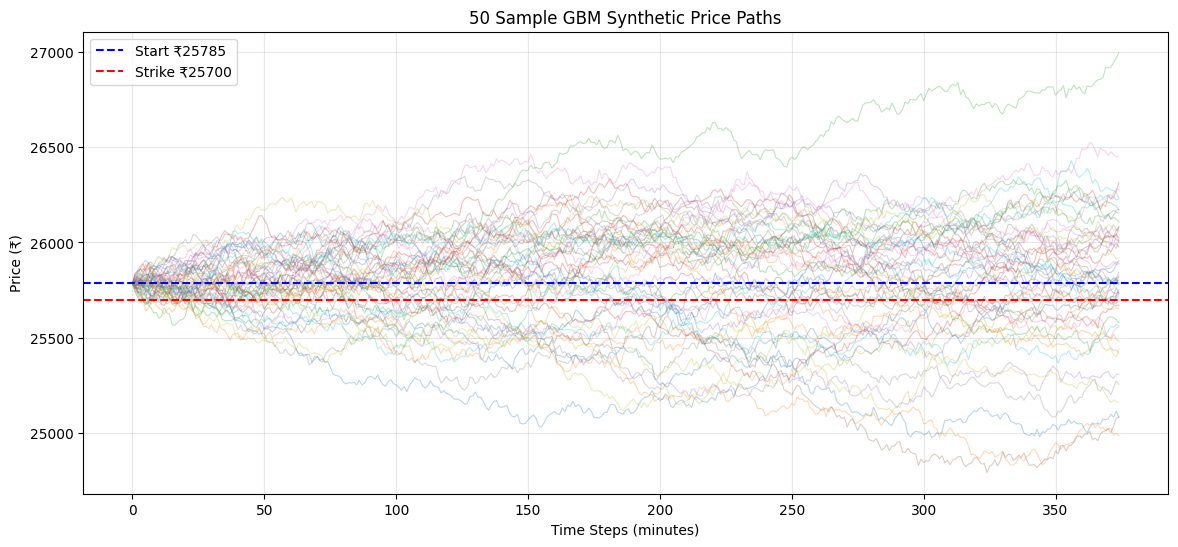

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Fix S0 to rupees
S0        = time_series_merged['last_trade_price_fut'].iloc[0] / 100
num_steps = len(time_series_merged) - 1

print(f"S0 (starting price): ₹{S0:.2f}")
print(f"Number of steps: {num_steps}")

# Calculate total time in years
time_diff = (
    time_series_merged['observation_datetime'].iloc[-1] -
    time_series_merged['observation_datetime'].iloc[0]
).total_seconds()

T_total_years = time_diff / (365.25 * 24 * 3600)
dt = T_total_years / num_steps

print(f"Total time (years): {T_total_years:.6f}")
print(f"dt per minute (years): {dt:.8f}")

# GBM Parameters
mu        = r      # 0.05 risk free rate
sigma     = 0.6    # 60% volatility
num_paths = 1000   # number of synthetic paths

# GBM path generator function
def generate_gbm_path(S0, mu, sigma, dt, num_steps):
    """
    Generates a single price path using Geometric Brownian Motion.

    S_{t+1} = S_t * exp((mu - 0.5*sigma^2)*dt + sigma*sqrt(dt)*Z)

    Parameters:
        S0        : starting price
        mu        : drift (risk-free rate)
        sigma     : volatility
        dt        : time step in years
        num_steps : number of time steps

    Returns:
        prices : array of length num_steps+1
    """
    prices    = np.zeros(num_steps + 1)
    prices[0] = S0

    for i in range(1, num_steps + 1):
        Z          = np.random.normal(0, 1)
        prices[i]  = prices[i-1] * np.exp(
            (mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z
        )
    return prices

# Generate 1000 paths
np.random.seed(42)  # for reproducibility
synthetic_price_paths = []

for _ in range(num_paths):
    path = generate_gbm_path(S0, mu, sigma, dt, num_steps)
    synthetic_price_paths.append(path)

synthetic_price_paths = np.array(synthetic_price_paths)

print(f"\nGenerated {num_paths} synthetic price paths.")
print(f"Each path has {num_steps + 1} points.")
print(f"Shape of paths array: {synthetic_price_paths.shape}")
print(f"Initial price  (S0)  : ₹{S0:.2f}")
print(f"Drift          (mu)  : {mu}")
print(f"Volatility     (sigma): {sigma}")
print(f"Time step      (dt)  : {dt:.8f} years")

# Plot first 50 paths to visualize
plt.figure(figsize=(14, 6))
for i in range(50):
    plt.plot(synthetic_price_paths[i], alpha=0.3, linewidth=0.8)

plt.axhline(y=S0,              color='blue',  linestyle='--', linewidth=1.5, label=f'Start ₹{S0:.0f}')
plt.axhline(y=target_strike_rs, color='red',   linestyle='--', linewidth=1.5, label=f'Strike ₹{target_strike_rs:.0f}')

plt.title('50 Sample GBM Synthetic Price Paths')
plt.xlabel('Time Steps (minutes)')
plt.ylabel('Price (₹)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Visualization of Synthetic Price Paths

Let's plot the first few generated paths to get a sense of their behavior.

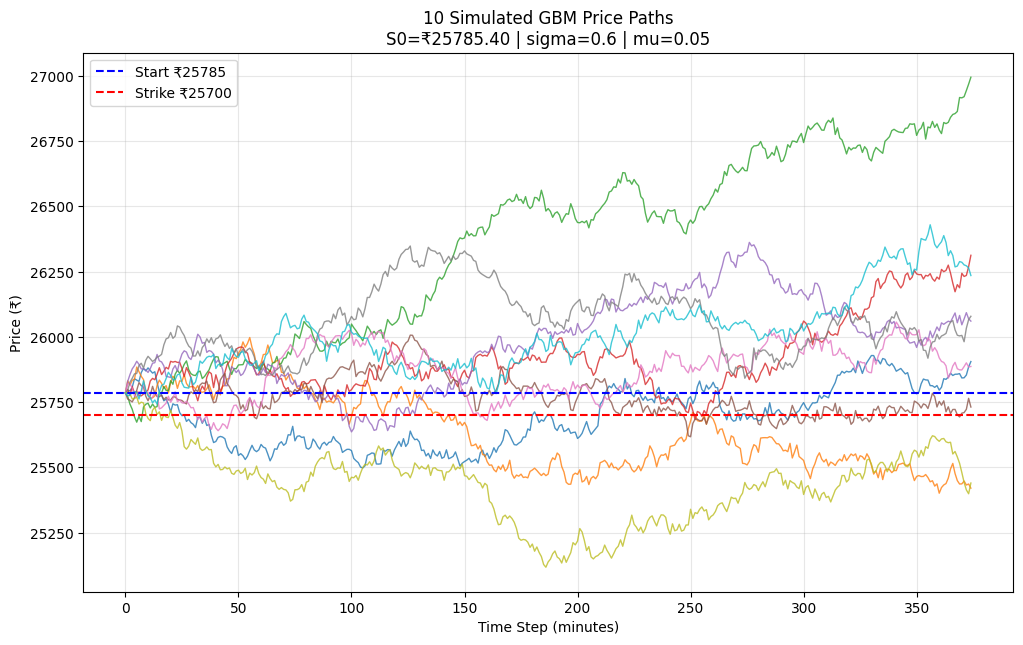

In [14]:
plt.figure(figsize=(12, 7))

for i in range(min(10, num_paths)):
    plt.plot(synthetic_price_paths[i], lw=1, alpha=0.8)

plt.axhline(y=S0, color='blue', linestyle='--', 
            linewidth=1.5, label=f'Start ₹{S0:.0f}')
plt.axhline(y=target_strike_rs, color='red', linestyle='--',
            linewidth=1.5, label=f'Strike ₹{target_strike_rs:.0f}')

plt.title(f'10 Simulated GBM Price Paths\n'
          f'S0=₹{S0:.2f} | sigma={sigma} | mu={mu}')
plt.xlabel('Time Step (minutes)')
plt.ylabel('Price (₹)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Next Steps for Training Data

Now that we have generated the underlying price paths, the next logical step is to:

1.  **Calculate Option Prices for each Path:** For each point in each simulated price path, we need to calculate the theoretical option price (and potentially its delta) using the Black-Scholes model. This will serve as the target for our deep hedging model or as input features.
2.  **Split into Training and Test Sets:** Divide these simulated paths into a training set for the RNN and a separate test set to evaluate its performance against delta hedging.
3.  **Implement the RNN Hedger:** Construct a simple RNN cell that takes inputs like `S_ti`, `I_ti` (e.g., Black-Scholes delta, volatility), and `δ_{ti-1}` to output the new hedge position `δ_ti`.

### Step 2: Calculate Black-Scholes Option Prices and Deltas for Synthetic Paths

For each generated GBM path, we need to calculate the theoretical Black-Scholes option price and its corresponding Delta at each time step. These will serve as target values and input features for our deep hedging model.


In [15]:
# Option parameters — use RUPEES not paise!
option_K          = target_strike_rs   # ₹25700 not 2570000
option_r          = r                  # 0.05
option_type       = 'call'
theoretical_sigma = sigma              # 0.6

all_bs_prices = []
all_bs_deltas = []

print(f"Calculating BS prices and deltas for {num_paths} paths...")
print(f"K=₹{option_K}, r={option_r}, sigma={theoretical_sigma}")

for path_idx, s_path in enumerate(synthetic_price_paths):
    bs_prices_for_path = []
    bs_deltas_for_path = []

    for t_step in range(num_steps + 1):
        S_t = s_path[t_step]

        # Time remaining decreases each minute
        T_remaining = max(0, T_total_years - (t_step * dt))

        # Calculate BS price and delta
        price, delta, _, _ = black_scholes(
            S_t, option_K, T_remaining,
            option_r, theoretical_sigma, option_type
        )

        bs_prices_for_path.append(price)
        bs_deltas_for_path.append(delta)

    all_bs_prices.append(np.array(bs_prices_for_path))
    all_bs_deltas.append(np.array(bs_deltas_for_path))

    # Progress update every 200 paths
    if (path_idx + 1) % 200 == 0:
        print(f"  Processed {path_idx + 1}/{num_paths} paths...")

# Convert to numpy arrays
all_bs_prices = np.array(all_bs_prices)
all_bs_deltas = np.array(all_bs_deltas)

print(f"\nDone! Shape: {all_bs_prices.shape}")
print(f"\nFirst path BS Prices (first 5): {all_bs_prices[0, :5].round(2)}")
print(f"First path BS Prices (last 5) : {all_bs_prices[0, -5:].round(2)}")
print(f"\nFirst path BS Deltas (first 5): {all_bs_deltas[0, :5].round(4)}")
print(f"First path BS Deltas (last 5) : {all_bs_deltas[0, -5:].round(4)}")

# Quick sanity check
print(f"\nDelta range across all paths: "
      f"{all_bs_deltas.min():.4f} to {all_bs_deltas.max():.4f}")
print(f"Price range across all paths: "
      f"₹{all_bs_prices.min():.2f} to ₹{all_bs_prices.max():.2f}")

Calculating BS prices and deltas for 1000 paths...
K=₹25700.0, r=0.05, sigma=0.6
  Processed 200/1000 paths...
  Processed 400/1000 paths...
  Processed 600/1000 paths...
  Processed 800/1000 paths...
  Processed 1000/1000 paths...

Done! Shape: (1000, 375)

First path BS Prices (first 5): [211.06 217.11 215.13 223.21 243.22]
First path BS Prices (last 5) : [142.65 143.16 153.8  184.85 205.39]

First path BS Deltas (first 5): [0.5861 0.5962 0.5935 0.6066 0.6369]
First path BS Deltas (last 5) : [0.9996 0.9999 1.     1.     1.    ]

Delta range across all paths: 0.0000 to 1.0000
Price range across all paths: ₹0.00 to ₹1505.97


### Step 3: Split Data into Training and Test Sets

We will now split the generated synthetic price paths, their corresponding Black-Scholes prices, and deltas into training and testing datasets. This is crucial for evaluating the performance of our Deep Hedger on unseen data.

In [16]:
from sklearn.model_selection import train_test_split

# Convert lists of arrays to a single numpy array if not already
synthetic_price_paths_array = np.array(synthetic_price_paths)

# Define the split ratio (e.g., 80% for training, 20% for testing)
test_size_ratio = 0.2

# Split the synthetic price paths
S_train, S_test = train_test_split(synthetic_price_paths_array, test_size=test_size_ratio, random_state=42)

# Split the corresponding Black-Scholes prices
BS_prices_train, BS_prices_test = train_test_split(all_bs_prices, test_size=test_size_ratio, random_state=42)

# Split the corresponding Black-Scholes deltas
BS_deltas_train, BS_deltas_test = train_test_split(all_bs_deltas, test_size=test_size_ratio, random_state=42)

print(f"Training set size: {len(S_train)} paths")
print(f"Test set size: {len(S_test)} paths")

print(f"Shape of S_train: {S_train.shape}")
print(f"Shape of BS_deltas_train: {BS_deltas_train.shape}")

Training set size: 800 paths
Test set size: 200 paths
Shape of S_train: (800, 375)
Shape of BS_deltas_train: (800, 375)


### Step 4: Implement the Deep Hedging RNN Model
We will now construct a simple Recurrent Neural Network (RNN) using TensorFlow/Keras to serve as our deep hedger. The goal of this RNN is to learn an optimal hedging strategy by outputting the next delta position based on current market information.

Our RNN will take the following inputs at each time step t:

S_t: The current underlying asset price.
BS_delta_t: The Black-Scholes delta at time t (using the theoretical sigma). This provides the model with relevant information about the option's sensitivity.
delta_{t-1}: The delta position held from the previous time step t-1. This allows the RNN to learn a dynamic hedging strategy, considering its past actions.
The RNN will output delta_t, the new delta position to be held for the next interval.

In [17]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Concatenate

# --- Model Parameters ---
num_dense_units = 32 # Number of units in the single Dense layer

# --- Input Layers for a single time step ---
# Input for current asset price (S_t) - single value per time step
s_input_t = Input(shape=(1,), name='S_t_input')

# Input for Black-Scholes delta (BS_delta_t) - single value per time step
bs_delta_input_t = Input(shape=(1,), name='BS_delta_t_input')

# Input for previous delta position (delta_{t-1}) - single value per time step
prev_delta_input_t = Input(shape=(1,), name='prev_delta_input')

# --- Feature Concatenation ---
# Concatenate S_t, BS_delta_t, and prev_delta_t as features for the Dense layer
combined_features_t = Concatenate(axis=-1)([s_input_t, bs_delta_input_t, prev_delta_input_t])

# --- Single Dense Layer ---
# The Dense layer will process the combined features
dense_output = Dense(num_dense_units, activation='tanh')(combined_features_t)
output_delta_t = Dense(1, activation='tanh', name='delta_t_output')(dense_output) # Final output layer

# --- Create the Model for a single time step ---
# Renaming to `deep_hedger_model` to distinguish from a full sequence model
deep_hedger_model = Model(inputs=[s_input_t, bs_delta_input_t, prev_delta_input_t], outputs=output_delta_t)

deep_hedger_model.summary()

print("Deep Hedging model implemented as a single-step predictor, incorporating previous delta.")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ S_t_input           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ BS_delta_t_input    │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ prev_delta_input    │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 3)         │          0 │ S_t_input[0][0],  │
│ (Concatenate)       │                   │            │ BS_delta_t_input… │
│                     │                   │            │ prev_delta_input… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │        128 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ delta_t_output      │ (None, 1)         │         33 │ dense[0][0]       │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 161 (644.00 B)

 Trainable params: 161 (644.00 B)

 Non-trainable params: 0 (0.00 B)

Deep Hedging model implemented as a single-step predictor, incorporating previous delta.


### Step 5: Define P&L Calculation and CVaR Loss Function (TensorFlow-compatible)

To train our deep hedger using CVaR as a loss function, we first need a TensorFlow-compatible way to calculate the P&L for a given hedging strategy (sequence of deltas) and a price path. Then, we'll define the CVaR loss itself.

#### P&L Calculation Function
This function will simulate the hedging process for a given path and sequence of deltas generated by the model. It will calculate the total P&L at expiry based on the formula: `PL_T = -Z(S) + (δ · S)_T` (assuming no transaction costs).

#### CVaR Loss Function
CVaR (Conditional Value at Risk), also known as Expected Shortfall, measures the expected loss beyond a certain percentile (VaR). For a hedging problem, we want to minimize the expected losses in the worst-case scenarios. If `P` is the distribution of P&L values, and `alpha` is the confidence level (e.g., 0.05 for 5%), then CVaR($\alpha$) is the expected P&L conditional on the P&L being below the $\alpha$-percentile (the VaR).

$$ \text{CVaR}_\alpha = E[\text{PL} | \text{PL} \le \text{VaR}_\alpha] $$


In [18]:
import tensorflow as tf

# Assuming option_K, r, option_type, dt are already defined globally or passed
# target_strike, r, option_type, dt

@tf.function
def calculate_pnl(S_path_batch, deltas_batch, K, r_tf, option_type_str):
    """
    Calculates the P&L for a batch of price paths and corresponding delta hedges.

    Args:
        S_path_batch (tf.Tensor): Batch of underlying price paths (batch_size, num_steps + 1).
        deltas_batch (tf.Tensor): Batch of delta hedges (batch_size, num_steps + 1).
                                 deltas_batch[..., t] is the delta held from t to t+1.
        K (tf.Tensor): Strike price.
        r_tf (tf.Tensor): Risk-free rate.
        option_type_str (tf.Tensor): String tensor indicating 'call' or 'put'.

    Returns:
        tf.Tensor: A tensor of P&L values for each path in the batch (batch_size,).
    """
    # Ensure tensors are float32 for consistency
    S_path_batch = tf.cast(S_path_batch, tf.float32)
    deltas_batch = tf.cast(deltas_batch, tf.float32)
    K = tf.cast(K, tf.float32)
    r_tf = tf.cast(r_tf, tf.float32)

    # Reshape deltas_batch to (batch_size, num_steps + 1) if it's (batch_size, num_steps + 1, 1)
    if len(deltas_batch.shape) == 3: # Handle case where delta_output is (batch_size, timesteps, 1)
        deltas_batch = tf.squeeze(deltas_batch, axis=-1)

    # S_t is S_path_batch[:, :-1]
    # S_{t+1} is S_path_batch[:, 1:]
    price_changes = S_path_batch[:, 1:] - S_path_batch[:, :-1]

    # Delta position at time t is held from t to t+1. So we use deltas_batch[:, :-1] (or just deltas_batch) for trading P&L
    # The last delta in deltas_batch is the delta at expiry, which contributes to the final option value, not trading PnL
    # This matches the (delta . S)_T definition in the paper where delta_ti is for (S_{ti+1} - S_ti)
    trading_pnl_per_interval = deltas_batch[:, :-1] * price_changes
    cumulative_trading_pnl = tf.reduce_sum(trading_pnl_per_interval, axis=1)

    # Option payoff at expiry (Z_T)
    S_T = S_path_batch[:, -1] # Final underlying price

    # Check option type using tf.strings.equal
    is_call = tf.cast(tf.strings.bytes_split(option_type_str)[0] == tf.constant(b'c'), tf.float32)

    option_payoff_at_expiry_call = tf.maximum(0.0, S_T - K)
    option_payoff_at_expiry_put = tf.maximum(0.0, K - S_T)

    # Use tf.where to select based on option type
    option_payoff_at_expiry = tf.where(
        tf.cast(is_call, tf.bool),
        option_payoff_at_expiry_call,
        option_payoff_at_expiry_put
    )

    # Total P&L: -Z_T + cumulative_trading_pnl (no transaction costs)
    total_pnl = -option_payoff_at_expiry + cumulative_trading_pnl

    return total_pnl

@tf.function
def cvar_loss(pnl_values, alpha=0.05):
    """
    Calculates the CVaR (Conditional Value at Risk) loss for a batch of P&L values.
    CVaR is the expected loss in the worst 'alpha' percentile.

    Args:
        pnl_values (tf.Tensor): A batch of P&L values (batch_size,).
        alpha (float): The significance level for CVaR (e.g., 0.05 for 5%).

    Returns:
        tf.Tensor: The CVaR loss (scalar).
    """
    # Sort P&L values in ascending order (from worst loss to best profit)
    sorted_pnl = tf.sort(pnl_values)

    # Calculate the index for VaR_alpha (worst 'alpha' percentage)
    num_samples = tf.cast(tf.shape(sorted_pnl)[0], tf.float32)
    cvar_index = tf.cast(tf.floor(num_samples * alpha), tf.int32)

    # Select the worst 'alpha' percentile of P&L values
    # Note: tf.slice is exclusive of the end index, so we need to go up to cvar_index
    worst_pnl_values = sorted_pnl[:cvar_index + 1] # Include up to the alpha-th percentile

    # CVaR is the negative of the average of these worst P&L values
    # We want to minimize the loss, so we minimize -CVaR or maximize CVaR.
    # Conventionally, CVaR is expressed as a positive loss, so we take the negative mean of P&L
    # PNL is profit, so minimizing average PNL means making profits smaller.
    # If PNL is negative (a loss), then -PNL is positive, and minimizing it means minimizing the loss.
    # So, CVaR loss will be -mean(worst_pnl_values)
    cvar_value = -tf.reduce_mean(worst_pnl_values)

    return cvar_value

print("TensorFlow-compatible P&L calculation and CVaR loss functions defined.")

TensorFlow-compatible P&L calculation and CVaR loss functions defined.


### Step 6: Implement Custom Training Loop for Deep Hedger

Now we will implement the custom training loop to train our `deep_hedger_model`. This loop will iterate through the synthetic training data, calculate the P&L for each generated path using the model's predicted deltas, compute the CVaR loss, and update the model's weights using an optimizer.

**Training Process:**
1.  **Initialize Optimizer:** We'll use the Adam optimizer.
2.  **Epochs and Batches:** The training will run for a specified number of epochs, and data will be processed in batches.
3.  **Dynamic Delta Prediction:** For each path in a batch, the model will predict the delta at each time step. Importantly, the `delta_prev` (the previous delta) will be fed back into the model as an input at each step, enabling the model to learn a sequential hedging strategy.
4.  **P&L Calculation:** After predicting all deltas for a path, the `calculate_pnl` function will be used to determine the P&L for that path.
5.  **CVaR Loss:** The `cvar_loss` function will then compute the Conditional Value at Risk based on the batch's P&L values.
6.  **Gradient Descent:** TensorFlow's `GradientTape` will automatically compute the gradients of the CVaR loss with respect to the model's trainable weights, and the optimizer will apply these gradients to update the weights.

In [19]:
import tensorflow as tf
import numpy as np

# ── Normalize prices ──────────────────────────────────────
S_mean = S_train.mean()
S_std  = S_train.std()

S_train_norm = (S_train - S_mean) / S_std
S_test_norm  = (S_test  - S_mean) / S_std

print(f"S_mean: {S_mean:.2f}, S_std: {S_std:.2f}")
print(f"Normalized range: {S_train_norm.min():.3f} to {S_train_norm.max():.3f}")

# ── Rebuild fresh model ───────────────────────────────────
tf.keras.backend.clear_session()

s_input_t        = tf.keras.Input(shape=(1,), name='S_t_input')
bs_delta_input_t = tf.keras.Input(shape=(1,), name='BS_delta_t_input')
prev_delta_input = tf.keras.Input(shape=(1,), name='prev_delta_input')

combined = tf.keras.layers.Concatenate()(
    [s_input_t, bs_delta_input_t, prev_delta_input])
hidden   = tf.keras.layers.Dense(64, activation='relu')(combined)
hidden2  = tf.keras.layers.Dense(32, activation='relu')(hidden)
output   = tf.keras.layers.Dense(1,  activation='sigmoid')(hidden2)

deep_hedger_model = tf.keras.Model(
    inputs=[s_input_t, bs_delta_input_t, prev_delta_input],
    outputs=output
)
deep_hedger_model.summary()

# ── Training setup ────────────────────────────────────────
optimizer      = tf.keras.optimizers.Adam(learning_rate=0.001)
epochs         = 50
batch_size     = 64
num_train_paths = S_train_norm.shape[0]
num_time_steps  = S_train_norm.shape[1]

train_dataset = tf.data.Dataset.from_tensor_slices(
    (S_train_norm.astype(np.float32),
     BS_deltas_train.astype(np.float32))
).shuffle(num_train_paths).batch(batch_size)

# ── Training loop ─────────────────────────────────────────
print(f"\nStarting Fixed Training for {epochs} epochs...")
history = []

for epoch in range(epochs):
    epoch_loss_avg = tf.keras.metrics.Mean()

    for batch_S_paths, batch_BS_deltas in train_dataset:
        with tf.GradientTape() as tape:

            delta_prev = tf.zeros(
                (tf.shape(batch_S_paths)[0], 1), dtype=tf.float32)
            all_deltas = []

            for t in range(num_time_steps):
                S_t       = tf.expand_dims(
                    batch_S_paths[:, t], axis=-1)
                BS_delta_t = tf.expand_dims(
                    batch_BS_deltas[:, t], axis=-1)

                delta_t    = deep_hedger_model(
                    [S_t, BS_delta_t, delta_prev],
                    training=True
                )
                all_deltas.append(delta_t)
                delta_prev = delta_t

            # Stack deltas → (batch, timesteps)
            deltas_seq = tf.squeeze(
                tf.transpose(
                    tf.stack(all_deltas, axis=0), perm=[1,0,2]
                ), axis=-1
            )

            # Use original (non-normalized) prices for P&L
            batch_S_original = (
                batch_S_paths * S_std + S_mean
            ).numpy().astype(np.float32)
            batch_S_original = tf.constant(batch_S_original)

            pnl = calculate_pnl(
                batch_S_original,
                deltas_seq,
                tf.constant(float(option_K),    dtype=tf.float32),
                tf.constant(float(option_r),     dtype=tf.float32),
                tf.constant(option_type,         dtype=tf.string)
            )
            loss = cvar_loss(pnl, alpha=0.05)

        grads = tape.gradient(
            loss, deep_hedger_model.trainable_variables)
        optimizer.apply_gradients(
            zip(grads, deep_hedger_model.trainable_variables))
        epoch_loss_avg.update_state(loss)

    epoch_loss_val = epoch_loss_avg.result().numpy()
    history.append(epoch_loss_val)

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:3d}/{epochs} — CVaR Loss: {epoch_loss_val:.4f}")

print("\nTraining Complete!")

# Plot training loss
plt.figure(figsize=(10, 4))
plt.plot(history, color='blue', linewidth=2)
plt.title('CVaR Loss During Training')
plt.xlabel('Epoch')
plt.ylabel('CVaR Loss')
plt.grid(True)
plt.show()

S_mean: 25785.69, S_std: 292.87
Normalized range: -4.651 to 4.849



Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ S_t_input           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ BS_delta_t_input    │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ prev_delta_input    │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 3)         │          0 │ S_t_input[0][0],  │
│ (Concatenate)       │                   │            │ BS_delta_t_input… │
│                     │                   │            │ prev_delta_input… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │        256 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      2,080 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         33 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,369 (9.25 KB)

 Trainable params: 2,369 (9.25 KB)

 Non-trainable params: 0 (0.00 B)


Starting Fixed Training for 50 epochs...
Epoch   5/50 — CVaR Loss: 270.9590


KeyboardInterrupt: 

In [ ]:
import numpy as np
import os

# Create saves folder
os.makedirs('saved_models', exist_ok=True)

# Save trained model
deep_hedger_model.save('saved_models/deep_hedger_model.keras')
print("✅ Model saved!")

# Save normalization values
np.save('saved_models/S_mean.npy', np.array([S_mean]))
np.save('saved_models/S_std.npy',  np.array([S_std]))
print("✅ Normalization saved!")

# Save test data
np.save('saved_models/S_test.npy',          S_test)
np.save('saved_models/S_test_norm.npy',     S_test_norm)
np.save('saved_models/BS_deltas_test.npy',  BS_deltas_test)
np.save('saved_models/BS_prices_test.npy',  BS_prices_test)
print("✅ Test data saved!")

# Save training history
np.save('saved_models/training_history.npy', np.array(history))
print("✅ Training history saved!")

# Save parameters
params = {
    'option_K'         : option_K,
    'option_r'         : option_r,
    'option_type'      : option_type,
    'target_strike_rs' : target_strike_rs,
    'sigma'            : sigma,
    'S0'               : S0,
    'num_steps'        : num_steps,
    'dt'               : dt,
    'S_mean'           : S_mean,
    'S_std'            : S_std,
}
np.save('saved_models/params.npy', params)
print("✅ Parameters saved!")

print("\n🎉 Everything saved successfully!")
print("\nFiles saved:")
for f in os.listdir('saved_models'):
    size = os.path.getsize(f'saved_models/{f}') / 1024
    print(f"  {f:35s} ({size:.1f} KB)")

✅ Model saved!
✅ Normalization saved!
✅ Test data saved!
✅ Training history saved!
✅ Parameters saved!

🎉 Everything saved successfully!

Files saved:
  BS_deltas_test.npy                  (586.1 KB)
  BS_prices_test.npy                  (586.1 KB)
  deep_hedger_model.keras             (36.4 KB)
  params.npy                          (0.5 KB)
  S_mean.npy                          (0.1 KB)
  S_std.npy                           (0.1 KB)
  S_test.npy                          (586.1 KB)
  S_test_norm.npy                     (586.1 KB)
  training_history.npy                (0.3 KB)


In [20]:
import numpy as np
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
import os

os.chdir(r"C:\Users\COMPUTER WORLD IT\OneDrive\Desktop\Delta Hedging & Adversarial Stock Path Generation Simulator")

# Load saved model
deep_hedger_model = tf.keras.models.load_model('saved_models/deep_hedger_model.keras')
print("✅ Model loaded!")

# Load normalization values
S_mean = np.load('saved_models/S_mean.npy')[0]
S_std  = np.load('saved_models/S_std.npy')[0]
print(f"✅ S_mean={S_mean:.2f}, S_std={S_std:.2f}")

# Load test data
S_test          = np.load('saved_models/S_test.npy')
S_test_norm     = np.load('saved_models/S_test_norm.npy')
BS_deltas_test  = np.load('saved_models/BS_deltas_test.npy')
BS_prices_test  = np.load('saved_models/BS_prices_test.npy')
print(f"✅ Test data loaded! Shape: {S_test.shape}")

# Load training history
history = np.load('saved_models/training_history.npy')
print(f"✅ Training history loaded! Final loss: {history[-1]:.4f}")

# Load parameters
params = np.load('saved_models/params.npy', allow_pickle=True).item()
option_K         = params['option_K']
option_r         = params['option_r']
option_type      = params['option_type']
target_strike_rs = params['target_strike_rs']
sigma            = params['sigma']
S0               = params['S0']
num_steps        = params['num_steps']
dt               = params['dt']
print(f"✅ Parameters loaded!")
print(f"   K=₹{option_K}, r={option_r}, sigma={sigma}")
print(f"   Strike=₹{target_strike_rs}, S0=₹{S0:.2f}")

# Redefine Black-Scholes
def black_scholes(S, K, T, r, sigma, option_type):
    if T <= 0:
        if option_type == 'call':
            delta = 1.0 if S > K else 0.0
            return max(0, S - K), delta, 0, 0
        else:
            delta = -1.0 if S < K else 0.0
            return max(0, K - S), delta, 0, 0
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    if option_type == 'call':
        price = S*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)
        delta = norm.cdf(d1)
        gamma = norm.pdf(d1) / (S*sigma*np.sqrt(T))
        theta = -(S*norm.pdf(d1)*sigma)/(2*np.sqrt(T)) - r*K*np.exp(-r*T)*norm.cdf(d2)
    else:
        price = K*np.exp(-r*T)*norm.cdf(-d2) - S*norm.cdf(-d1)
        delta = norm.cdf(d1) - 1
        gamma = norm.pdf(d1) / (S*sigma*np.sqrt(T))
        theta = -(S*norm.pdf(d1)*sigma)/(2*np.sqrt(T)) + r*K*np.exp(-r*T)*norm.cdf(-d2)
    return price, delta, gamma, theta

# Redefine calculate_pnl and cvar_loss
@tf.function
def calculate_pnl(S_path_batch, deltas_batch, K, r_tf, option_type_str):
    S_path_batch = tf.cast(S_path_batch, tf.float32)
    deltas_batch = tf.cast(deltas_batch, tf.float32)
    K    = tf.cast(K,    tf.float32)
    r_tf = tf.cast(r_tf, tf.float32)
    if len(deltas_batch.shape) == 3:
        deltas_batch = tf.squeeze(deltas_batch, axis=-1)
    price_changes        = S_path_batch[:, 1:] - S_path_batch[:, :-1]
    trading_pnl          = tf.reduce_sum(deltas_batch[:, :-1] * price_changes, axis=1)
    S_T                  = S_path_batch[:, -1]
    is_call              = tf.cast(
        tf.strings.bytes_split(option_type_str)[0] == tf.constant(b'c'), tf.float32)
    payoff_call          = tf.maximum(0.0, S_T - K)
    payoff_put           = tf.maximum(0.0, K - S_T)
    payoff               = tf.where(tf.cast(is_call, tf.bool), payoff_call, payoff_put)
    return -payoff + trading_pnl

@tf.function
def cvar_loss(pnl_values, alpha=0.05):
    sorted_pnl   = tf.sort(pnl_values)
    num_samples  = tf.cast(tf.shape(sorted_pnl)[0], tf.float32)
    cvar_index   = tf.cast(tf.floor(num_samples * alpha), tf.int32)
    worst_pnl    = sorted_pnl[:cvar_index + 1]
    return -tf.reduce_mean(worst_pnl)

print("\n✅ All functions redefined!")
print("\n🚀 Ready to continue!")

✅ Model loaded!
✅ S_mean=25785.69, S_std=292.87
✅ Test data loaded! Shape: (200, 375)
✅ Training history loaded! Final loss: 237.8787
✅ Parameters loaded!
   K=₹25700.0, r=0.05, sigma=0.6
   Strike=₹25700.0, S0=₹25785.40

✅ All functions redefined!

🚀 Ready to continue!


### Step 7: Evaluate Model Performance

Now that the deep hedging model is trained, we need to evaluate its performance against the traditional Black-Scholes delta hedging strategy on both the synthetic training and test datasets. This will involve:

1.  **Calculating P&L** for the Deep Hedger and Black-Scholes Delta Hedger for each path in the train and test sets.
2.  **Plotting P&L distributions** (histograms) to visually compare the hedging effectiveness.
3.  **Quantifying risk** by calculating Value at Risk (VaR) and Conditional Value at Risk (CVaR) for each scenario.

In [22]:
import tensorflow as tf
import numpy as np

num_time_steps = S_test_norm.shape[1]

# ── Helper: predict deltas for paths ─────────────────────────
def predict_deltas_batch(model, S_paths_norm, BS_deltas, num_time_steps):
    all_deltas = []
    batch_size = S_paths_norm.shape[0]

    for i in range(batch_size):
        s_path     = S_paths_norm[i].astype(np.float32)
        bs_path    = BS_deltas[i].astype(np.float32)
        delta_prev = np.zeros((1, 1), dtype=np.float32)
        path_deltas = []

        for t in range(num_time_steps):
            S_t        = np.array([[s_path[t]]], dtype=np.float32)
            BS_delta_t = np.array([[bs_path[t]]], dtype=np.float32)
            delta_t    = model([S_t, BS_delta_t, delta_prev], training=False).numpy()
            path_deltas.append(delta_t[0, 0])
            delta_prev = delta_t

        all_deltas.append(path_deltas)
        if (i + 1) % 50 == 0:
            print(f"  Processed {i+1}/{batch_size} paths...")

    return np.array(all_deltas)

# ── Deep Hedger P&L on Test Set ──────────────────────────────
print("Predicting deltas for Deep Hedger on Test Set...")
dh_predicted_deltas_test = predict_deltas_batch(
    deep_hedger_model, S_test_norm, BS_deltas_test, num_time_steps
)
print(f"Predicted deltas shape: {dh_predicted_deltas_test.shape}")

dh_pnl_test = calculate_pnl(
    tf.constant(S_test.astype(np.float32)),
    tf.constant(dh_predicted_deltas_test.astype(np.float32)),
    tf.constant(float(option_K), dtype=tf.float32),
    tf.constant(float(option_r), dtype=tf.float32),
    tf.constant(option_type, dtype=tf.string)
).numpy()

print(f"\nDeep Hedger Test P&L:")
print(f"  Mean P&L : Rs {dh_pnl_test.mean():.2f}")
print(f"  Std P&L  : Rs {dh_pnl_test.std():.2f}")
print(f"  Min P&L  : Rs {dh_pnl_test.min():.2f}")
print(f"  Max P&L  : Rs {dh_pnl_test.max():.2f}")

# ── Black-Scholes Hedger P&L on Test Set ─────────────────────
print("\nCalculating Black-Scholes Hedger P&L on Test Set...")
bs_pnl_test = calculate_pnl(
    tf.constant(S_test.astype(np.float32)),
    tf.constant(BS_deltas_test.astype(np.float32)),
    tf.constant(float(option_K), dtype=tf.float32),
    tf.constant(float(option_r), dtype=tf.float32),
    tf.constant(option_type, dtype=tf.string)
).numpy()

print(f"\nBlack-Scholes Test P&L:")
print(f"  Mean P&L : Rs {bs_pnl_test.mean():.2f}")
print(f"  Std P&L  : Rs {bs_pnl_test.std():.2f}")
print(f"  Min P&L  : Rs {bs_pnl_test.min():.2f}")
print(f"  Max P&L  : Rs {bs_pnl_test.max():.2f}")

# ── VaR and CVaR comparison ───────────────────────────────────
def compute_var_cvar(pnl_array, alpha=0.05):
    sorted_pnl = np.sort(pnl_array)
    n   = len(sorted_pnl)
    idx = int(np.floor(n * alpha))
    var  = sorted_pnl[idx]
    cvar = sorted_pnl[:idx+1].mean()
    return var, cvar

dh_var,  dh_cvar  = compute_var_cvar(dh_pnl_test)
bs_var,  bs_cvar  = compute_var_cvar(bs_pnl_test)

print(f"\n{'='*50}")
print(f"RISK COMPARISON (95% confidence level)")
print(f"{'='*50}")
print(f"{'Metric':<20} {'Deep Hedger':>14} {'BS Hedger':>14}")
print(f"{'-'*50}")
print(f"{'Mean P&L':<20} Rs {dh_pnl_test.mean():>10.2f} Rs {bs_pnl_test.mean():>10.2f}")
print(f"{'Std P&L':<20} Rs {dh_pnl_test.std():>10.2f} Rs {bs_pnl_test.std():>10.2f}")
print(f"{'VaR (95%)':<20} Rs {dh_var:>10.2f} Rs {bs_var:>10.2f}")
print(f"{'CVaR (95%)':<20} Rs {dh_cvar:>10.2f} Rs {bs_cvar:>10.2f}")
print(f"{'='*50}")

Predicting deltas for Deep Hedger on Test Set...
  Processed 50/200 paths...
  Processed 100/200 paths...
  Processed 150/200 paths...
  Processed 200/200 paths...
Predicted deltas shape: (200, 375)

Deep Hedger Test P&L:
  Mean P&L : Rs -211.37
  Std P&L  : Rs 16.86
  Min P&L  : Rs -245.87
  Max P&L  : Rs -158.96

Calculating Black-Scholes Hedger P&L on Test Set...

Black-Scholes Test P&L:
  Mean P&L : Rs -212.11
  Std P&L  : Rs 8.28
  Min P&L  : Rs -242.56
  Max P&L  : Rs -189.58

RISK COMPARISON (95% confidence level)
Metric                  Deep Hedger      BS Hedger
--------------------------------------------------
Mean P&L             Rs    -211.37 Rs    -212.11
Std P&L              Rs      16.86 Rs       8.28
VaR (95%)            Rs    -234.70 Rs    -224.96
CVaR (95%)           Rs    -239.60 Rs    -232.39
